In [1]:
!pip install squidpy
!pip install cellcharter
!pip install lightning
!pip install scvi-colab
!pip install --upgrade networkx

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.3/161.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Restart session
exit()

In [1]:
# Install SCVI
import scvi_colab

scvi_colab.install()
!pip install scvi-tools

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


In [2]:
!pip uninstall scipy && pip install scipy

Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/scipy-1.14.1.dist-info/*
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libscipy_openblas-c128ec02.so
    /usr/local/lib/python3.11/dist-packages/scipy/*
Proceed (Y/n)? Y
  Successfully uninstalled scipy-1.14.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 17.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

In [3]:
!pip uninstall seaborn && pip install seaborn

Y
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/seaborn-0.13.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/seaborn/*
Proceed (Y/n)?   Successfully uninstalled seaborn-0.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.1 MB/s eta 0:00:00


In [4]:
# Restart session
exit()

In [1]:
# Importing the necessary libraries
import os
import gc
import scvi
import scipy
import torch
import random
import anndata

import numpy as np
import pandas as pd
import seaborn as sns
import squidpy as sq
import lightning as pl
import cellcharter as cc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from lightning.pytorch import seed_everything
from scipy.sparse.csgraph import connected_components

/usr/local/lib/python3.11/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
print("Scvi-tools version:", scvi.__version__)

Scvi-tools version: 1.3.1.post1


In [3]:
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed, for the repeatability
    of the experiment.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    scvi.settings.seed = seed
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [4]:
from google.colab import drive
drive.mount('/content/drive')
TRAIN_ANNDATA_PATH = '/content/drive/MyDrive/data/train_adata.h5ad'

sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 9)

train_anndata = anndata.read_h5ad(TRAIN_ANNDATA_PATH)
print(train_anndata)

Mounted at /content/drive
AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier'
    var: 'channel', 'use_channel', 'marker'
    layers: 'exprs'


# PCA

In [5]:
# Standardisation for PCA on cells' marker expression
expressions = train_anndata.layers['exprs']
total_counts = expressions.sum(axis=1, keepdims=True)
norm_exprs = (expressions / total_counts) * 1e4
norm_exprs = np.log1p(norm_exprs)
train_anndata.layers['normalised_exprs'] = norm_exprs

# PCA explaining 100% of variance
pca = PCA(svd_solver='full')
pca_exprs = pca.fit_transform(norm_exprs)
print(f"PCA: Number of components = {pca_exprs.shape[1]}, Explained variance = {pca.explained_variance_ratio_.sum():.2f}")

train_anndata.obsm['X_PCA'] = pca_exprs

PCA: Number of components = 40, Explained variance = 1.00


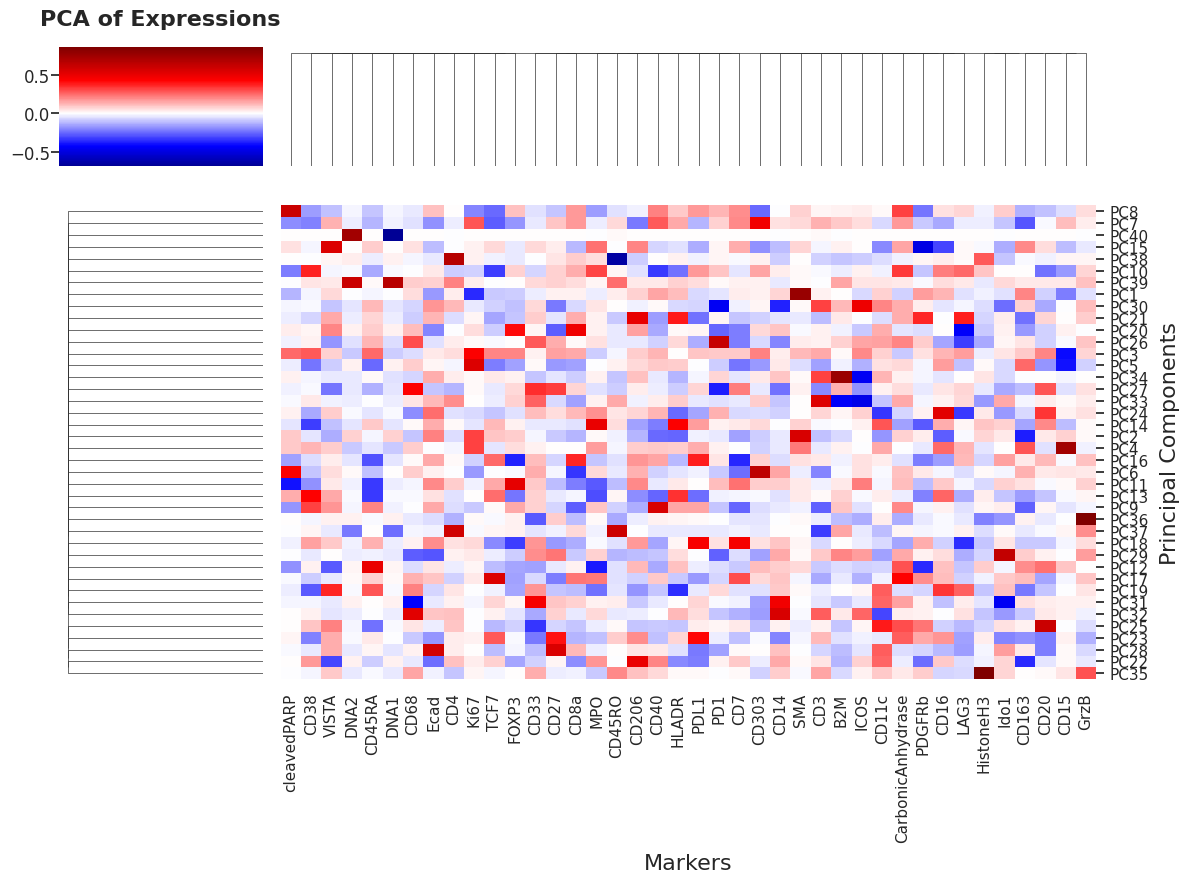

In [6]:
def plot_clustermap(data: pd.DataFrame,
                    x_labels: pd.DataFrame,
                    shape: int,
                    title: str) -> None:
    """ Helper function for plotting clustermap.
    """
    plot = sns.clustermap(
        data,
        cmap='seismic',
        center=0.0,
        xticklabels=x_labels,
        yticklabels=[f"PC{idx+1}" for idx in range(shape)],
        figsize=plt.rcParams['figure.figsize'],
    )

    # Improved layout for the plot
    cbar = plot.ax_heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12,
                        pad=0.10,
                        labelleft=True,
                        labelright=False,
                        left=True,
                        right=False
    )

    plot.ax_heatmap.set_xlabel('Markers', fontsize=16, labelpad=8)
    plot.ax_heatmap.set_ylabel('Principal Components', fontsize=16, labelpad=8)
    plt.title(title, fontsize=16, pad=16, loc='center', weight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()


plot_clustermap(pca.components_,
                train_anndata.var['marker'],
                pca_exprs.shape[1],
                'PCA of Expressions'
)

# Cellcharter again

In [7]:
def plot_heatmap(data: pd.DataFrame,
                 title: str,
                 fmt: str,
                 figsize: tuple = None,
                 xlabel: str = "Cell Types") -> None:
    """ Helper function for plotting heatmap.
    """
    if figsize:
        plt.figure(figsize=figsize)
        sns.heatmap(data, annot=True, fmt=fmt, cmap=sns.cubehelix_palette(as_cmap=True))
    else:
        plt.figure(figsize=plt.rcParams['figure.figsize'])
        sns.heatmap(data, annot=True, fmt=fmt, cmap="crest")

    plt.title(title, weight='bold', fontsize=20, pad=12)
    plt.xlabel(xlabel, fontsize=16, labelpad=8)
    plt.ylabel("Clusters", fontsize=16, labelpad=8)
    plt.tight_layout()
    plt.show()
    plt.close()

In [8]:
train_anndata.obsm['spatial'] = train_anndata.obs[['Pos_X', 'Pos_Y']].values

sq.gr.spatial_neighbors(
    train_anndata,
    library_key='sample_id',
    coord_type='generic',
    delaunay=True,
    spatial_key='spatial',
    percentile=99,
)

In [9]:
cc.gr.aggregate_neighbors(
    train_anndata,
    n_layers=4,
    use_rep='X_PCA',
    out_key='X_cellcharter',
    sample_key='sample_id'
)

  0%|          | 0/132 [00:00<?, ?it/s]

In [10]:
# Defining params for AutoK model to find best candidate for the number of clusters
n_clusters = range(2, 16)
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

model_params = {
        'random_state': 42,
        'trainer_params': {
            'accelerator': accelerator,
            'enable_progress_bar': False
        },
}

In [11]:
model = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                           model_class=cc.tl.GaussianMixture,
                           model_params=model_params,
                           max_runs=8
)

# Change to float32 for compatibility of numpy and torch
train_anndata.obsm["X_cellcharter"] = train_anndata.obsm["X_cellcharter"].astype(np.float32)

# Taking every 10th example to faster computations
model.fit(train_anndata[::10], use_rep='X_cellcharter')

Iteration 1/8


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/8


  0%|          | 0/14 [00:00<?, ?it/s]

...

  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 8/8


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

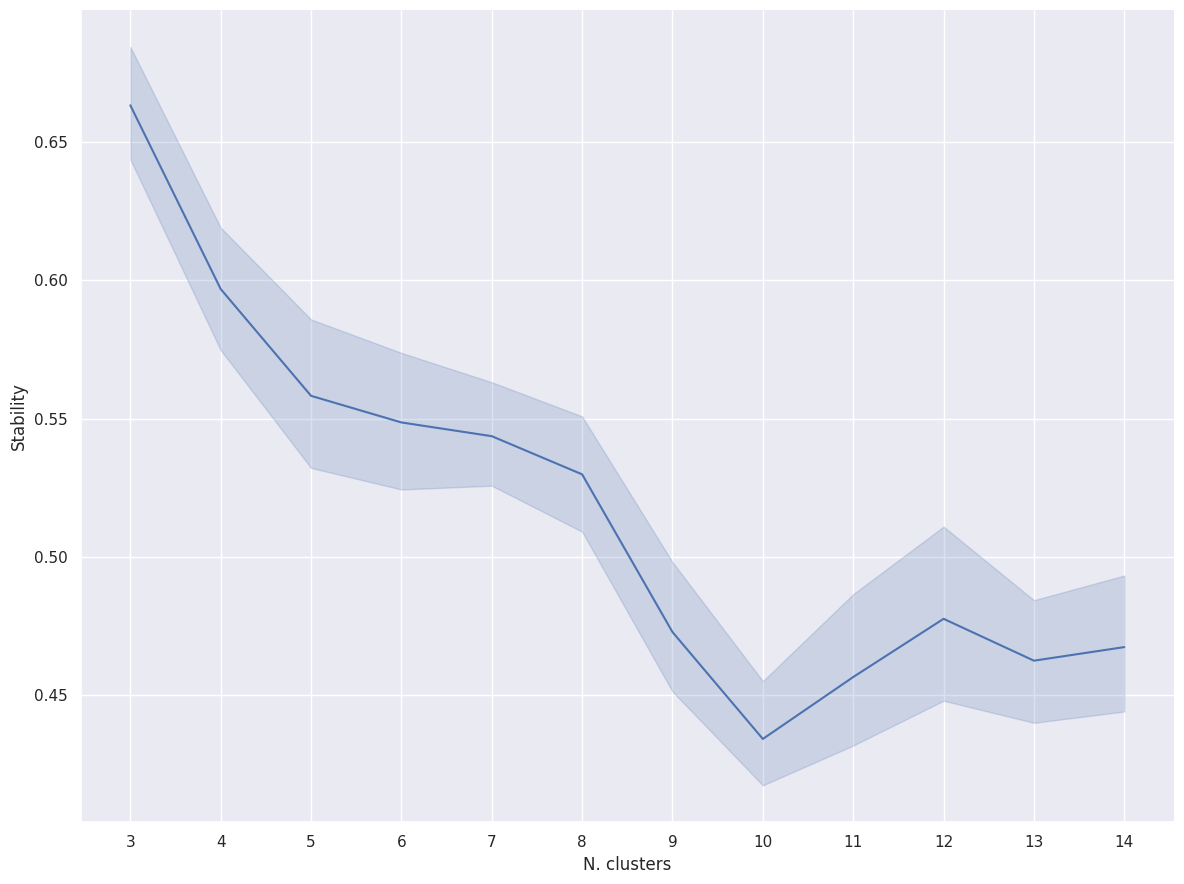

In [12]:
# Choose the best number of clusters with peaks of stability
cc.pl.autok_stability(model)
plt.tight_layout()
plt.show()
plt.close()

In [13]:
best_cluster = model.best_k
print(f"In our case for PCA, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_cellcharter'] = model.predict(train_anndata, use_rep='X_cellcharter', k=best_cluster)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In our case for PCA, 3 is the best candidate!


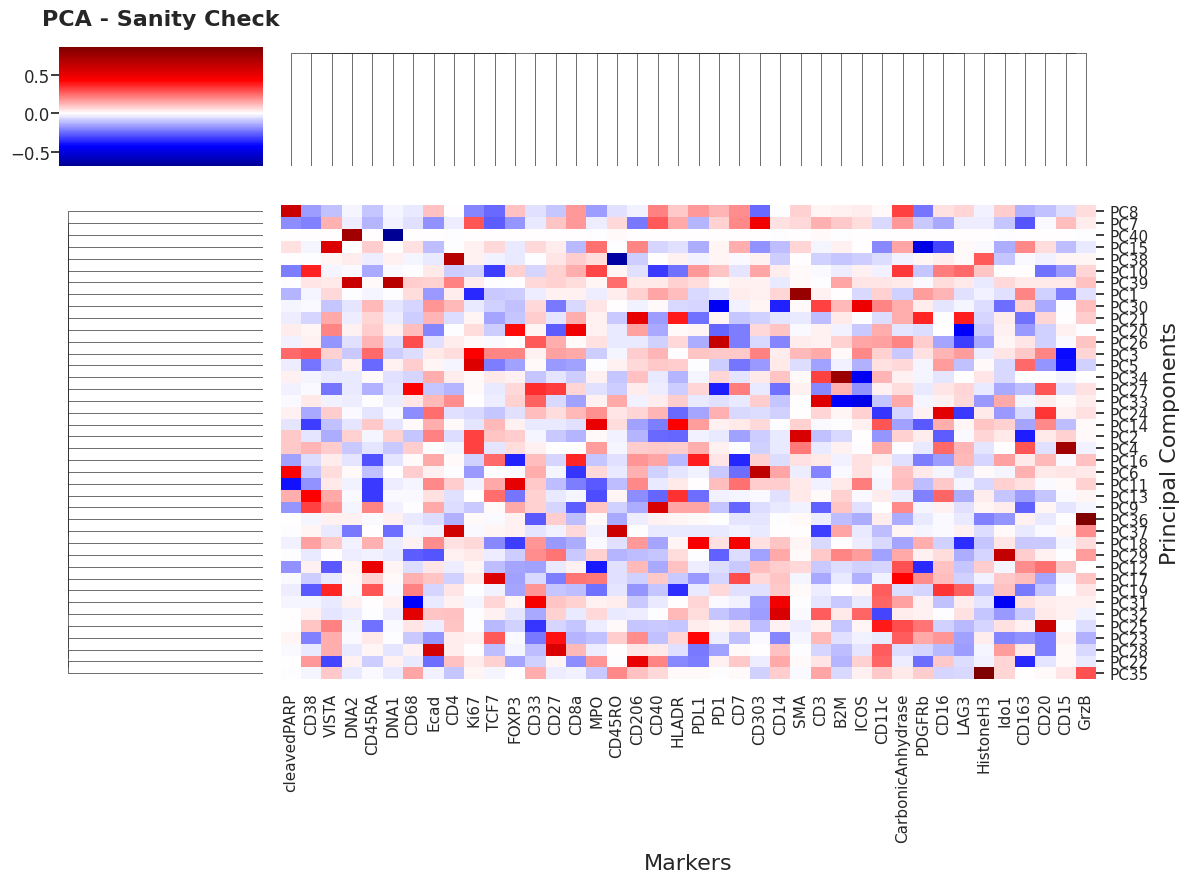

In [14]:
# Sanity check for PCA
cluster_pca_model = PCA(svd_solver='full')
cluster_pca_exprs = cluster_pca_model.fit_transform(train_anndata.layers['normalised_exprs'])

plot_clustermap(cluster_pca_model.components_,
                train_anndata.var['marker'],
                cluster_pca_exprs.shape[1],
                'PCA - Sanity Check'
)

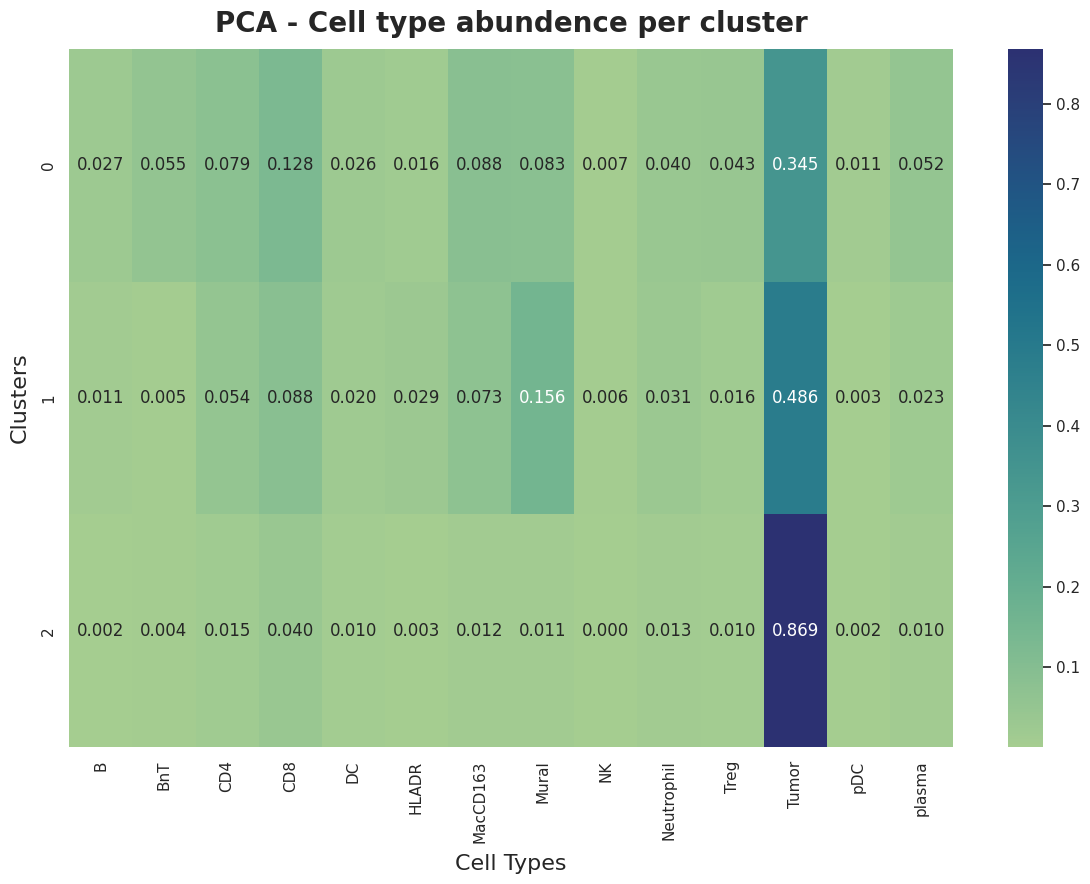

In [15]:
# Cell type abundance
cell_type_abundance = train_anndata.obs.groupby('cluster_cellcharter', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "PCA - Cell type abundence per cluster", ".3f")

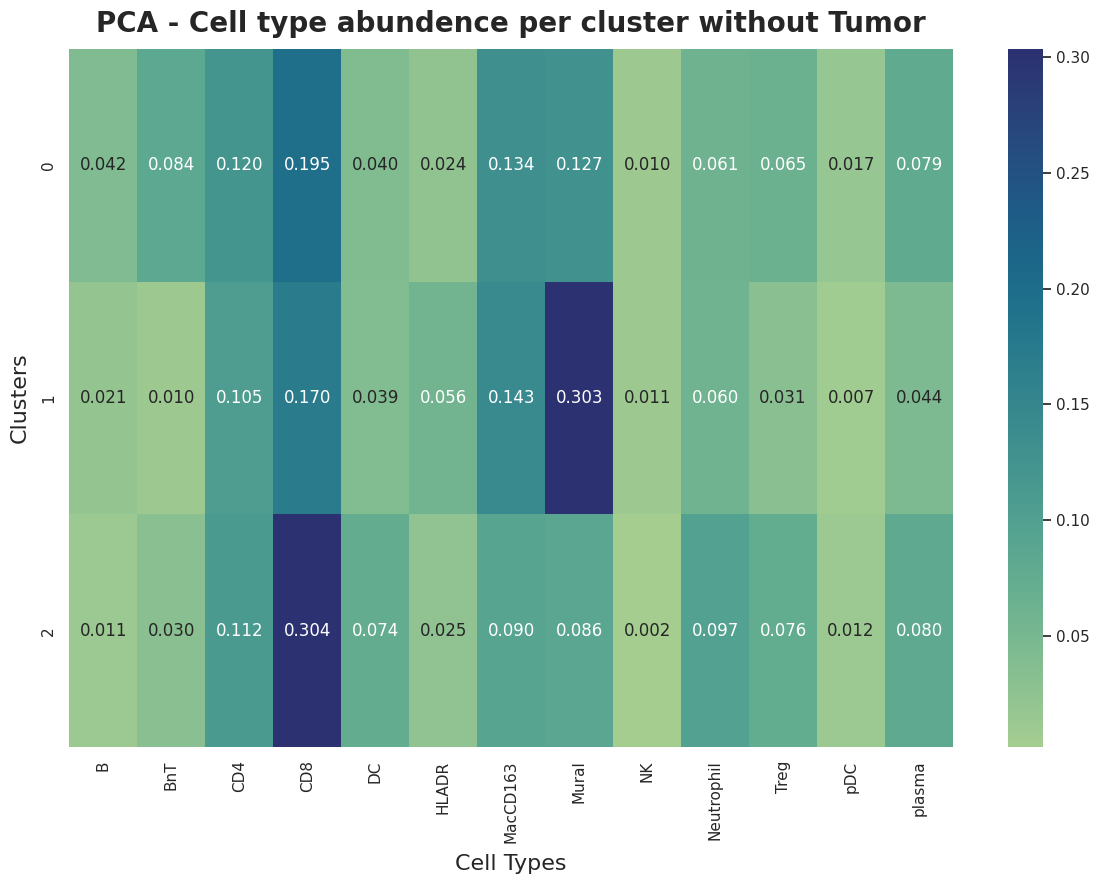

In [16]:
# Cell type abundance without Tumor
cell_type_abundance = train_anndata.obs.groupby('cluster_cellcharter', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "PCA - Cell type abundence per cluster without Tumor", ".3f")

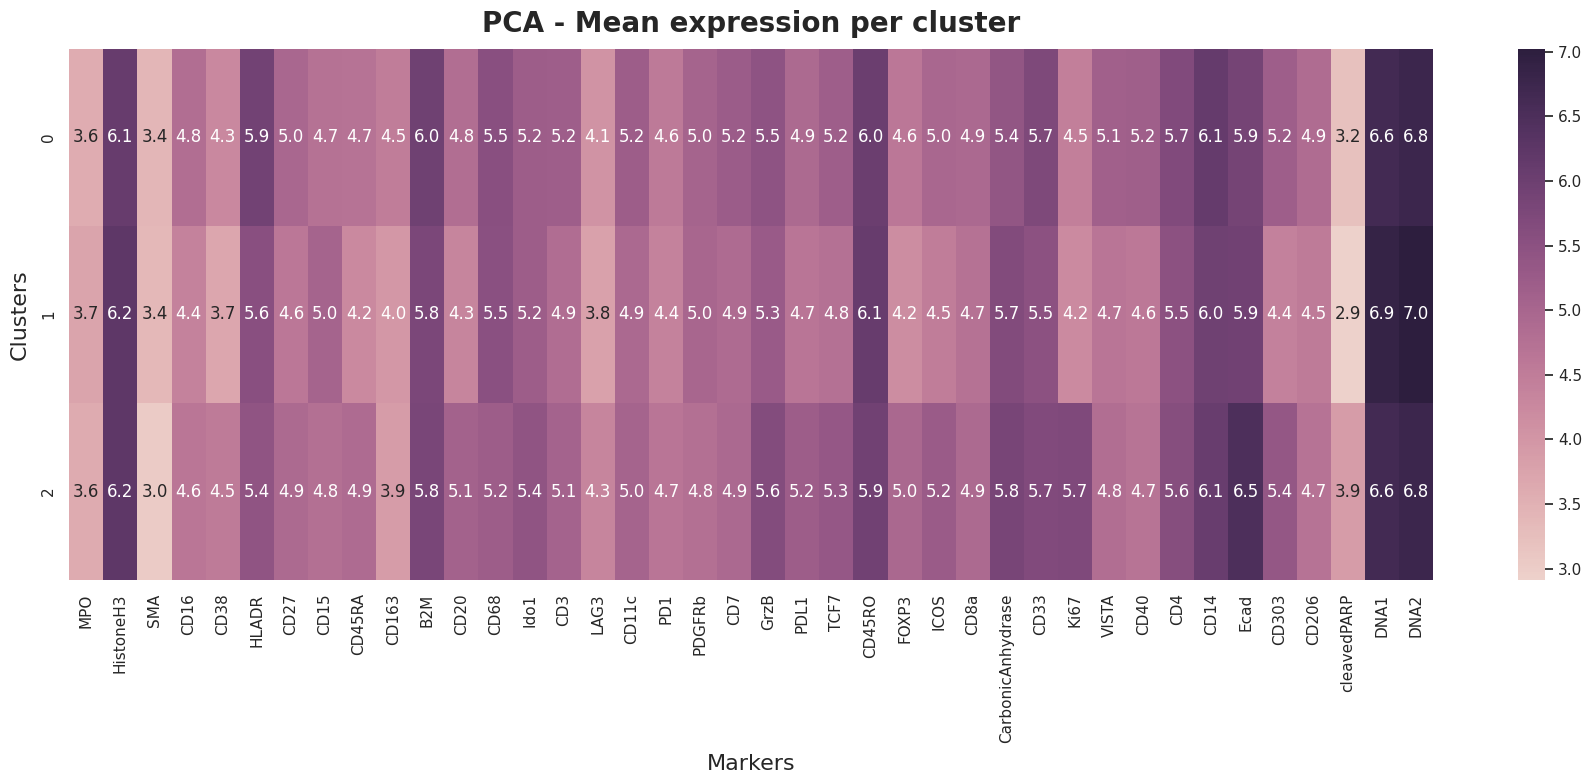

In [17]:
# Mean marker analysis
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_cellcharter'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

# Make DataFrame to plot
expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "PCA - Mean expression per cluster", ".1f", (18, 8), "Markers")

Using the Cellchanter algorithm, based on the results obtained with PCA, 3 cell clusters were obtained. Each of them is dominated by cancer cells. In the one that is not completely dominated by them, CD8+ cells, which are crucial for cellular immunity and can kill virus-infected cells or cancer cells, also appear noticeably. In each cluster, CD4+ cells co-occur at a similar level, helping to activate other immune cells such as B lymphocytes and macrophages. Also key in one cluster is the presence of Mural cells that form the walls of blood vessels, such as pericytes and smooth muscle cells. The increased presence of Mural cells in tumour areas may reflect a process of intensive angiogenesis, i.e. the formation of a network of blood vessels necessary for tumour nutrition and growth. The presence and interaction of Mural cells with tumour cells, may have an impact on tumour aggressiveness.

This is also confirmed by the presence of the fibroblast marker SMA, which is more present in clusters with fewer tumour cells. In most cases, in clusters with fewer tumour cells, the markers are more abundant, the exceptions being Ki67, Ecad, cleavendPARP. Ki67 is a nuclear protein that is present in cells only during the active phase of the cell cycle, i.e. indicative of tumour cell proliferation.  In most cases, the markers are more abundant in clusters with fewer tumour cells, with the exceptions of Ki67, Ecad and cleaved PARP. Ki67 is a nuclear protein present only during the active phase of the cell cycle and therefore indicative of tumour cell proliferation. Ecad is a marker of E-cadherin, an adhesion protein found in epithelial cells. Lower expression of Ecad is often associated with transformation, which indicates tumour progression. Conversely, higher levels of cleaved PARP, a marker of apoptosis, may indicate areas where the active process of cell death is occurring. This may be related to the potential outcome of therapies targeting cancer cells, among other factors.

# scVI

In [18]:
scvi.model.SCVI.setup_anndata(train_anndata,
                              layer="exprs",
                              batch_key="Batch"
)

model = scvi.model.SCVI(train_anndata,
                        n_latent=40,
                        gene_likelihood="nb"
)
model.train(max_epochs=100,
            accelerator=accelerator,
            early_stopping=True,
            enable_progress_bar=True
)

/usr/local/lib/python3.11/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[exprs] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [19]:
latent = model.get_latent_representation()
train_anndata.obsm["X_SCVI"] = latent

In [20]:
cc.gr.aggregate_neighbors(
train_anndata,
n_layers=4,
use_rep='X_SCVI',
out_key='X_agg_SCVI',
sample_key='sample_id'
)

  0%|          | 0/132 [00:00<?, ?it/s]

In [21]:
model_scvi = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                                model_class=cc.tl.GaussianMixture,
                                model_params=model_params,
                                max_runs=8
)

train_anndata.obsm["X_agg_SCVI"] = train_anndata.obsm["X_agg_SCVI"].astype(np.float32)

model_scvi.fit(train_anndata[::10], use_rep='X_agg_SCVI')

Iteration 1/8


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/8


  0%|          | 0/14 [00:00<?, ?it/s]

...

  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 8/8


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

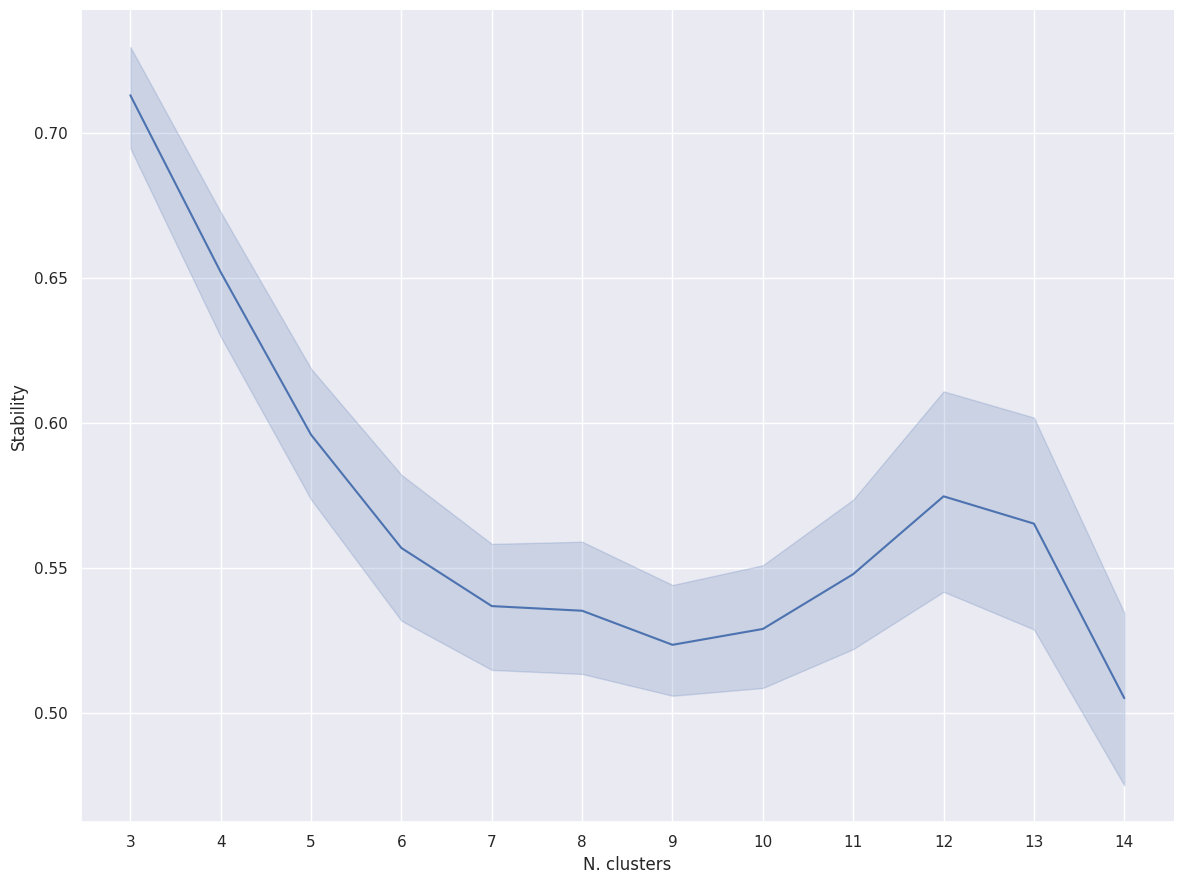

In [22]:
cc.pl.autok_stability(model_scvi)
plt.tight_layout()
plt.show()
plt.close()

In [23]:
best_cluster = model_scvi.best_k
print(f"In SCVI case, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_scvi'] = model_scvi.predict(train_anndata, use_rep='X_agg_SCVI', k=best_cluster)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In SCVI case, 3 is the best candidate!


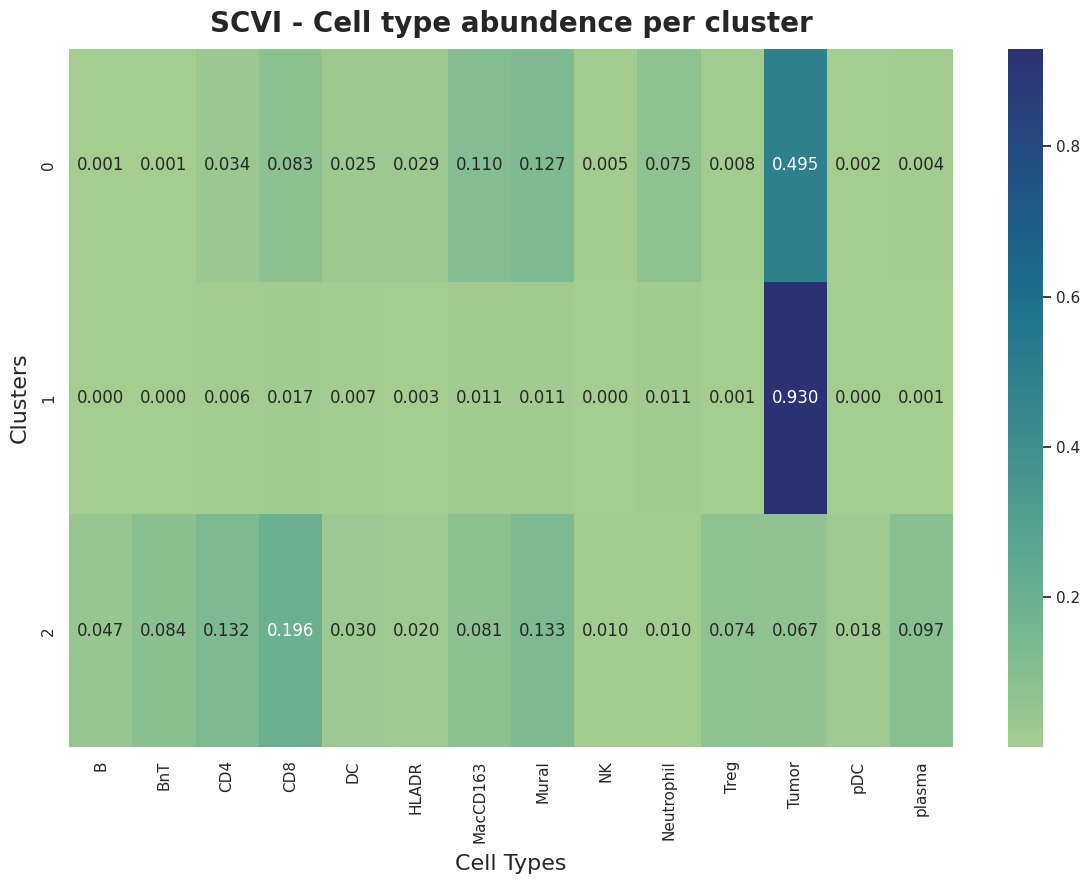

In [24]:
# Cell type abundance SCVI
cell_type_abundance = train_anndata.obs.groupby('cluster_scvi', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "SCVI - Cell type abundence per cluster", ".3f")

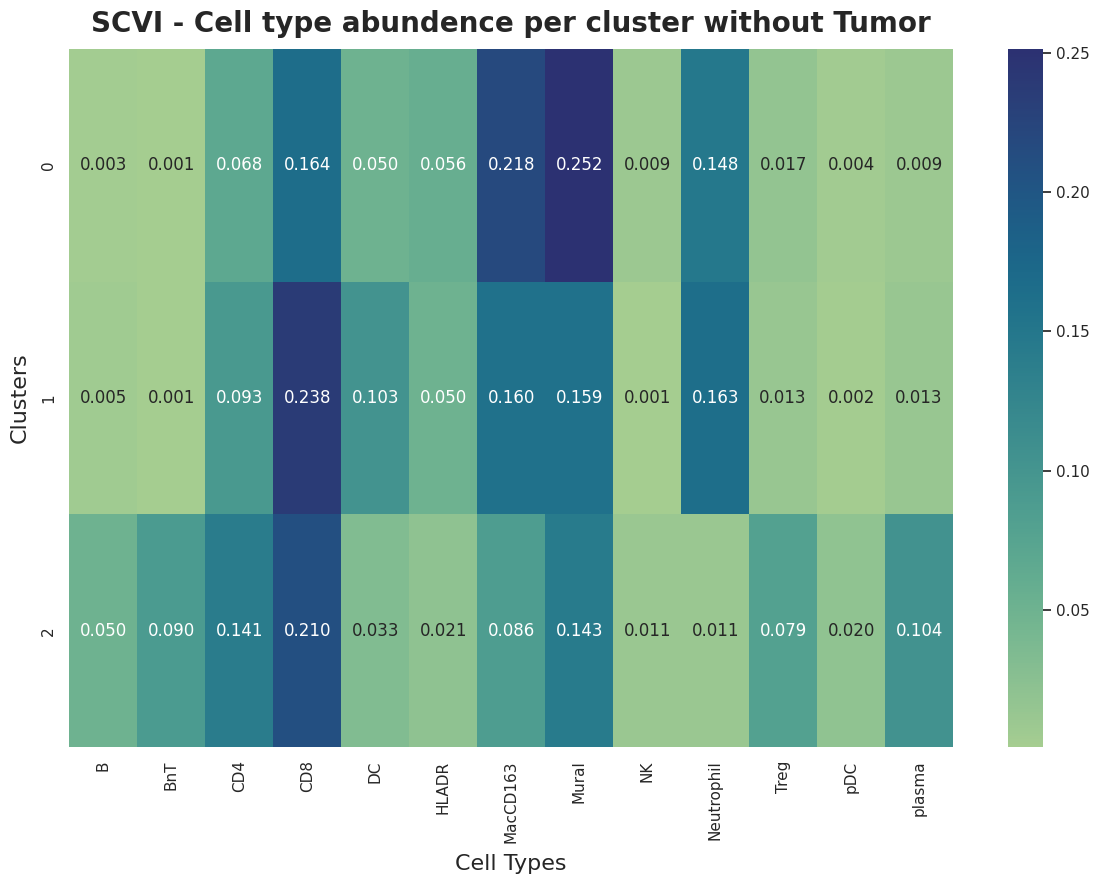

In [25]:
# Cell type abundance without Tumor SCVI
cell_type_abundance = train_anndata.obs.groupby('cluster_scvi', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "SCVI - Cell type abundence per cluster without Tumor", ".3f")

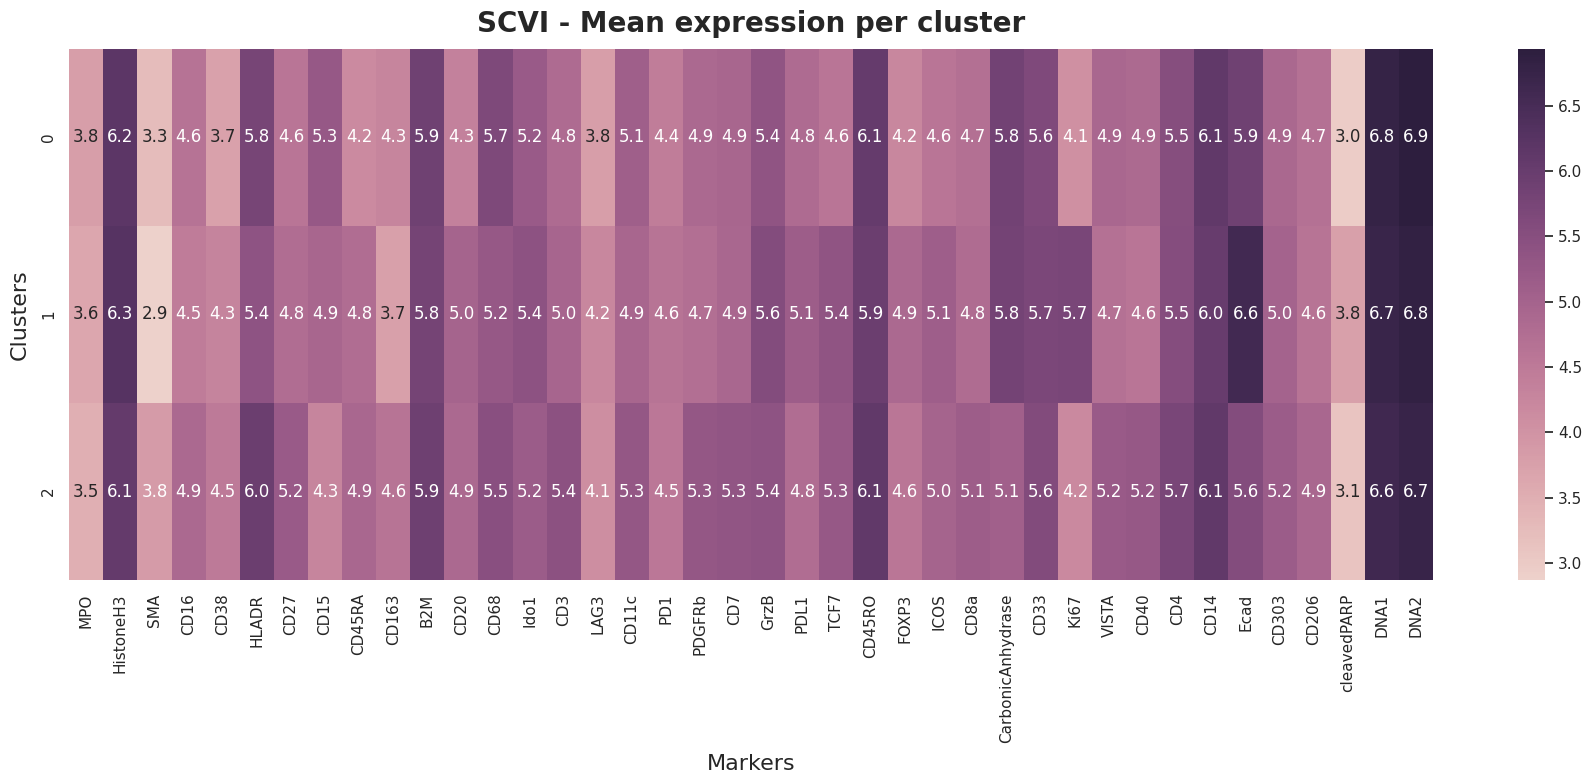

In [26]:
# Mean marker analysis SCVI
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_scvi'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "SCVI - Mean expression per cluster", ".1f", (18, 8), "Markers")

Based on the scVI (single-cell Variational Inference) algorithm, we also obtain 3 clusters of cells. The first two are similar from what we obtained using PCA. We have a cluster that is completely dominated by cancer cells, and one with a medium incidence (in PCA this included two clusters). However, using this method, we also obtained a cluster in which cancer cells are not present in the greatest number. The model using the fact that we have *de facto* with sparse data managed to find a cluster of data with interesting properties. The cluster without cancer is co-dominated by B cells, BnT cells indicating a large number of both B cells and T cells. This shows the body's response to cancer at the sites in question. This is also confirmed by the number of plasma cells, which are fully differentiated B cells that produce antibodies in large numbers. The occurrence of a cluster of these cells shows where the boundary of the tumor and the current battlefield is. This is also demonstrated by the presence of CD163 macrophages, which are associated with promoting tumor growth, and Treg cells. They are a specialized subtype of CD4+ T cells, whose main role is to suppress the immune response. They help prevent autoimmunity and maintain immune tolerance. They suppress the immune system's effective fight against cancer.


This is also confirmed by markers in this cluster, such as CD11c, CD3, HLA-DR. The former indicates the presence of dendritic cells, which play a key role in triggering the immune response, both innate and adaptive. CD3 is a marker for all T cells. In contrast, high expression of HLA-DR on tumor cells is an indicator of antigens and T-cell activation. High expression of HLA-DR on antigen-presenting cells in a tumor may be associated with an active anti-tumor immune response.


In [27]:
# Clear cache
gc.collect()

54588

# Comparison

In [28]:
def make_cross_matrix(obs, col1, col2, normalize=True):
    """ Function returns a DataFrame with a
    cross-sectional matrix and percentages.
    """
    ct = pd.crosstab(obs[col1], obs[col2])
    if normalize:
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        return ct, ct_pct

    return ct, None


def plot_cross_heatmap(ct_raw, ct_pct, title: str) -> None:
    """ Function plots a heatmap of a cross-count matrix.
    """
    plt.figure(figsize=plt.rcParams['figure.figsize'])
    ax = sns.heatmap(
        ct_raw,
        annot=False,
        fmt='d',
        cmap='YlOrBr',
        cbar_kws={'label': 'Number of Cells', 'pad': 0.05}
    )

    for i in range(ct_raw.shape[0]):
        for j in range(ct_raw.shape[1]):
            raw = ct_raw.iloc[i, j]
            pct = ct_pct.iloc[i, j]
            color = 'white' if raw >= 37000 else 'black'
            ax.text(
                j + 0.5, i + 0.4,
                f"{raw}",
                ha='center', va='center',
                color=color,
                fontsize=12, weight='bold'
            )
            ax.text(
                j + 0.5, i + 0.6,
                f"({pct:.1f}%)",
                ha='center', va='center',
                color=color,
                fontsize=8
            )

    ax.set_title(title, fontsize=16, pad=12, weight='bold')
    ax.set_xlabel(ct_raw.columns.name or '', fontsize=12)
    ax.set_ylabel(ct_raw.index.name or '', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()

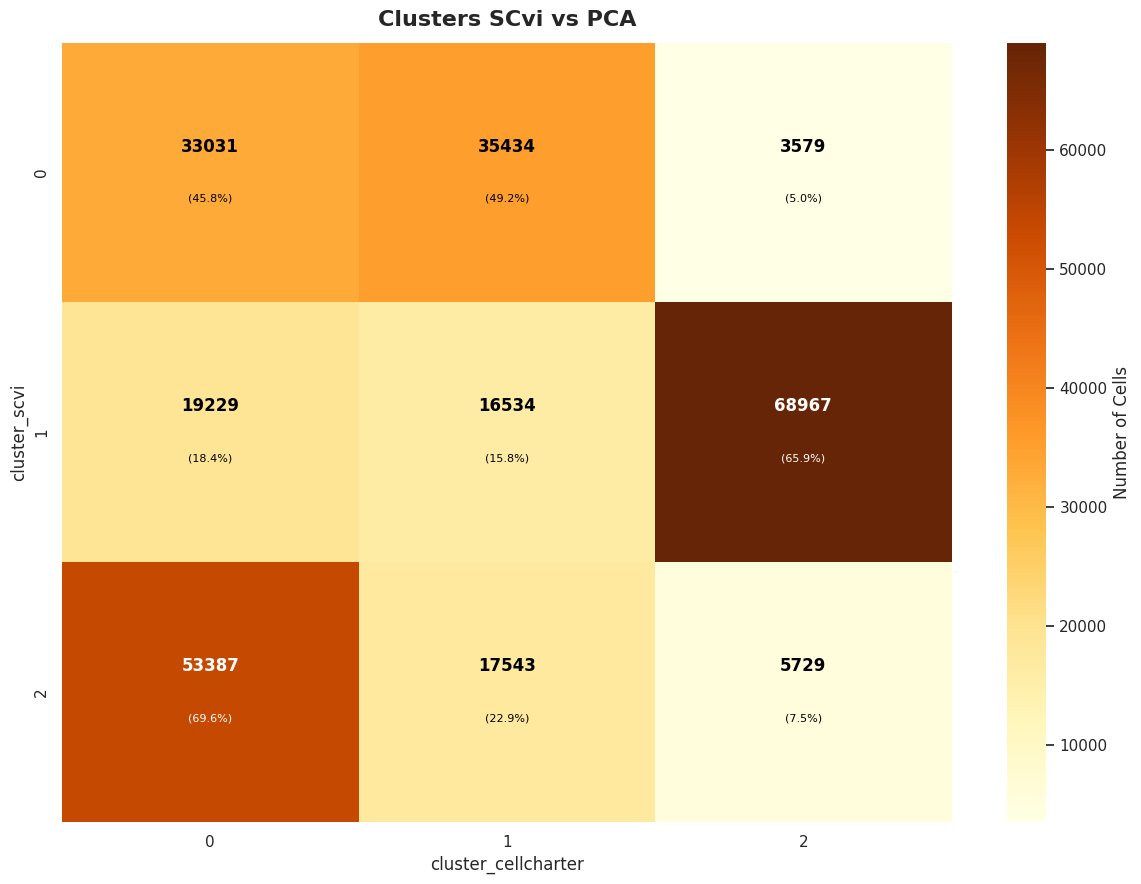

In [29]:
for name_a, name_b in [('cluster_scvi','cluster_cellcharter')]:
    ct_left, ct_right = make_cross_matrix(train_anndata.obs, name_a, name_b)
    plot_cross_heatmap(ct_left, ct_right, f"Clusters SCvi vs PCA")

The above hypotheses are confirmed by comparing the number of cells *per cluster*. For the scVI method, cluster 2, overlaps 70% with cluster 0 obtained by the PCA method, for the group with the lowest number of tumor cells. In contrast, clusters 1 of the scVI algorithm and 2 of the PCA method correspond to the clusters with the highest intensity of cancer cells. Cluster 0 scVI, on the other hand, is distributed between two other clusters with similar cancer cell ratios. This seems to prove that although the scVI algorithm returned the same number of clusters, they are much better at differentiating the data we analyzed.

# BERT-Charter

In [30]:
import networkx as nx
import torch.nn as nn
import scipy.sparse as sp
import torch.optim as optim
import torch.nn.functional as F

from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.nn import TransformerEncoder, TransformerEncoderLayer

In [31]:
gc.collect()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_LAYERS = 4

In [35]:
print(train_anndata)
print("Number of markers:",train_anndata.n_vars)

AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier', 'cluster_cellcharter', '_scvi_batch', '_scvi_labels', 'cluster_scvi'
    var: 'channel', 'use_channel', 'marker'
    uns: 'spatial_neighbors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_PCA', 'spatial', 'X_cellcharter', 'X_SCVI', 'X_agg_SCVI'
    layers: 'exprs', 'normalised_exprs'
    obsp: 'spatial_connectivities', 'spatial_distances'
Number of markers: 40


In [42]:
class NeighborhoodDataset(Dataset):
    def __init__(self,
                 adata: anndata.AnnData,
                 n_layers: int = 4):
        """ Dataset returning for the i-th cell and n_layers will
        return n_layers of sets of cells:
          - distance 0 - the original cell,
          - distance 1 - the nearest neighbours,
          - ...,
          - distance n_layers - 1 - cells distant by the length of the shortest path n_layers - 1 in the graph.
          - will return the sequence of all cell marker expressions and the layer number +1 of each cell (central
          cell = 1, immediate neighbours = 2, etc.).
        """
        self.adata = adata
        self.n_layers = n_layers
        self.neighbor_inds = []

        Matrix: sp.spmatrix = adata.obsp['spatial_connectivities']
        Graph = nx.from_scipy_sparse_array(Matrix)

        # Compute the shortest-path to n_layers-1
        for i in range(Matrix.shape[0]):
            lengths = nx.single_source_shortest_path_length(Graph, i, cutoff=n_layers-1)
            layers = [[] for _ in range(n_layers)]
            for node, dist in lengths.items():
                layers[dist].append(node)

            self.neighbor_inds.append(layers)

    def __len__(self):
        return self.adata.n_obs

    def __getitem__(self, idx):
        layers_list = self.neighbor_inds[idx]
        expression_list, layer_idx_list = [], []

        for traversal, nodes in enumerate(layers_list):
            if not nodes:
                continue

            layer_idx_list.append(torch.full((len(nodes),), traversal+1))
            exprs_np = self.adata.layers['exprs'][nodes]
            expression_list.append(torch.from_numpy(exprs_np).float())

        # Combines all traversials
        layer_ids = torch.cat(layer_idx_list, dim=0)
        exprs = torch.cat(expression_list, dim=0)
        return layer_ids, exprs

In [43]:
class NeighborhoodEmbedder(nn.Module):
    def __init__(self,
                 input_dim: int = 40,
                 embedding_dim: int = 128,
                 n_layers: int = 4):
        """ The class will take the collection from the NeighborhoodDataset,
        and return a sequence of dimension embedding_dim, for each cell:
          - will calculate the sum of the linear embedding of marker expression,
          - will add a learnable layer number embedding,
          - for cells with layer number 0, replace the embedding of expression
                                        by a mask vector of dimension embedding_dim.
        """
        super().__init__()
        self.expression_emb = nn.Linear(input_dim, embedding_dim)
        self.layer_emb = nn.Embedding(n_layers+1, embedding_dim)
        self.mask_vector = nn.Parameter(torch.randn(embedding_dim))

    def forward(self, layers, exprs):
        x = self.expression_emb(exprs)
        mask_cond = (layers == 0)
        mask_cond = mask_cond.unsqueeze(-1)

        mask_vec = self.mask_vector.unsqueeze(0).unsqueeze(0).expand_as(x)
        mask_cond_expanded = mask_cond.expand_as(x)

        x = torch.where(mask_cond_expanded, mask_vec, x)

        layer_embedding = self.layer_emb(layers)
        x = x + layer_embedding
        return x

In [44]:
class BertCharter(nn.Module):
    def __init__(self,
                 input_dim: int,
                 model_dim: int,
                 n_layers_embed: int,
                 n_transformer_layers: int = 4,
                 n_heads: int = 4):
        """ The class uses the NeighborhoodEmbedder, thanks to the TransformerEncoder.
        It passes the output of the last encoder layer to a linear layer with the dimension
        of the number of markers.

        Returns:
          - the output sequence from the last encoder layer,
          - sequence for marker prediction.
        """
        super().__init__()
        self.embedder = NeighborhoodEmbedder(input_dim, model_dim, n_layers_embed)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=n_heads, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.head = nn.Linear(model_dim, input_dim)

    def forward(self, layers: torch.LongTensor, exprs: torch.FloatTensor):
        x = self.embedder(layers, exprs)
        x = self.transformer(x)
        out = self.head(x)
        return x, out

In [45]:
def collate_fn(batch):
    """
    The function takes a list of different sequence lengths (layer_ids, exprs) and
    generalises them into a single array. It inserts a fill value of 0 to create a coherent batch,
    which is then ready to be passed to the model. Of course, tensors of the same shape are required for this.
    """
    layers_list, exprs_list = zip(*batch)
    layers_padded = torch.nn.utils.rnn.pad_sequence(layers_list, batch_first=True, padding_value=0)
    exprs_padded = torch.nn.utils.rnn.pad_sequence(exprs_list, batch_first=True, padding_value=0.0)
    return layers_padded, exprs_padded

In [46]:
def train_with_validation(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    device: torch.device,
    save_path: str = "best_model.pt",
    mask_prob: float = 0.15,
    weight_mask: float = 1.0,
    weight_nomask: float = 0.1,
    loss_fn = F.mse_loss
):
    """ Function performs a full cycle of training the model with simultaneous
    quality checks on the validation set and recording the best state of the weights.
    """
    model.to(device)
    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch} [TRAIN]")
        running_train_loss = 0.0

        for i, (layers, exprs) in enumerate(train_pbar):
            layers = layers.to(device)
            exprs  = exprs.to(device)

            batch, cells, _ = exprs.shape
            mask = (torch.rand((batch, cells), device=device) < mask_prob)
            layers_masked = layers.clone()
            layers_masked[mask] = 0

            optimizer.zero_grad()
            _, preds = model(layers_masked, exprs)
            loss_mse = loss_fn(preds, exprs, reduction='none')
            weights = torch.where(
                mask.unsqueeze(-1),
                weight_mask * torch.ones((batch, cells, 1), device=device),
                weight_nomask * torch.ones((batch, cells, 1), device=device)
            )
            loss = (loss_mse * weights).mean()
            loss.backward()
            optimizer.step()
            running_train_loss = (running_train_loss * i + loss.item()) / (i + 1)
            train_pbar.set_postfix({'Train Loss': running_train_loss})

        print(f"Epoch: {epoch} - TRAIN LOSS: {running_train_loss:.4f}")

        model.eval()
        val_pbar = tqdm(val_loader, desc=f"Epoch: {epoch} [VAL]")
        running_val_loss = 0.0
        count = 0

        with torch.no_grad():
            for i, (layers_val, exprs_val) in enumerate(val_pbar):
                layers_val = layers_val.to(device)
                exprs_val  = exprs_val.to(device)
                batch, cells, _ = exprs_val.shape

                mask_val = (torch.rand((batch, cells), device=device) < mask_prob)
                layers_val_masked = layers_val.clone()
                layers_val_masked[mask_val] = 0

                # Forward pass
                _, preds_val = model(layers_val_masked, exprs_val)
                loss_mse_val = loss_fn(preds_val, exprs_val, reduction='none')

                weights_val = torch.where(
                    mask_val.unsqueeze(-1),
                    weight_mask * torch.ones((batch, cells, 1), device=device),
                    weight_nomask * torch.ones((batch, cells, 1), device=device)
                )
                loss_val = (loss_mse_val * weights_val).mean()
                running_val_loss = (running_val_loss * count + loss_val.item()) / (count + 1)
                count += 1
                val_pbar.set_postfix({'val_loss': running_val_loss})

        print(f"Epoch: {epoch} - VAL LOSS: {running_val_loss:.4f}")

        if running_val_loss < best_val_loss:
            print(f"Validation loss improved ({best_val_loss:.4f} -> {running_val_loss:.4f}). Saving model to {save_path}")
            best_val_loss = running_val_loss
            torch.save(model.state_dict(), save_path)


    print("Training complete. Best validation loss: {:.4f}".format(best_val_loss))

In [47]:
dataset = NeighborhoodDataset(train_anndata, N_LAYERS)
train_idx, val_idx = train_test_split(
    np.arange(len(dataset)), test_size=0.1, random_state=42
)

train_subset = torch.utils.data.Subset(dataset, train_idx)
val_subset = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [48]:
model = BertCharter(
    input_dim=train_anndata.n_vars,
    model_dim=128,
    n_layers_embed=N_LAYERS,
    n_transformer_layers=4,
    n_heads=4
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())

train_with_validation(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=8,
    device=DEVICE,
    save_path="bertcharter_best.pt",
    mask_prob=0.15,
    weight_mask=1.0,
    weight_nomask=0.1,
    loss_fn=F.mse_loss
)

model.load_state_dict(torch.load("bertcharter_best.pt"))

Epoch 1 [TRAIN]:   0%|          | 0/7128 [00:00<?, ?it/s]

Epoch: 1 - TRAIN LOSS: 0.1599


Epoch: 1 [VAL]:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch: 1 - VAL LOSS: 0.1638
Validation loss improved (inf -> 0.1638). Saving model to bertcharter_best.pt


Epoch 2 [TRAIN]:   0%|          | 0/7128 [00:00<?, ?it/s]

...

Epoch 8 [TRAIN]:   0%|          | 0/7128 [00:00<?, ?it/s]

Epoch: 8 - TRAIN LOSS: 0.1551


Epoch: 8 [VAL]:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch: 8 - VAL LOSS: 0.1630
Training complete. Best validation loss: 0.1630


<All keys matched successfully>

In [60]:
data_bert = []
model.eval()
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

with torch.no_grad():
    pbar = tqdm(loader)
    for layers, exprs in pbar:
        layers = layers.to(DEVICE)
        exprs  = exprs.to(DEVICE)

        x_sequences, _ = model(layers, exprs)
        x_mean = x_sequences.mean(dim=1)
        x_np = x_mean.cpu().numpy()

        data_bert.append(x_np)

data_bert = np.concatenate(data_bert, axis=0)

  0%|          | 0/7920 [00:00<?, ?it/s]

In [61]:
train_anndata.obsm['X_BERT'] = data_bert

cc.gr.aggregate_neighbors(
    train_anndata,
    n_layers=N_LAYERS,
    use_rep='X_BERT',
    out_key='X_agg_BERT',
    sample_key='sample_id'
)

train_anndata.obsm['X_agg_BERT'] = train_anndata.obsm['X_agg_BERT'].astype(np.float32)

  0%|          | 0/132 [00:00<?, ?it/s]

In [62]:
model_bert = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                               model_class=cc.tl.GaussianMixture,
                               model_params=model_params,
                               max_runs=8
)

model_bert.fit(train_anndata[::10], use_rep='X_agg_BERT')

Iteration 1/8


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/8


  0%|          | 0/14 [00:00<?, ?it/s]

...

  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 8/8


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

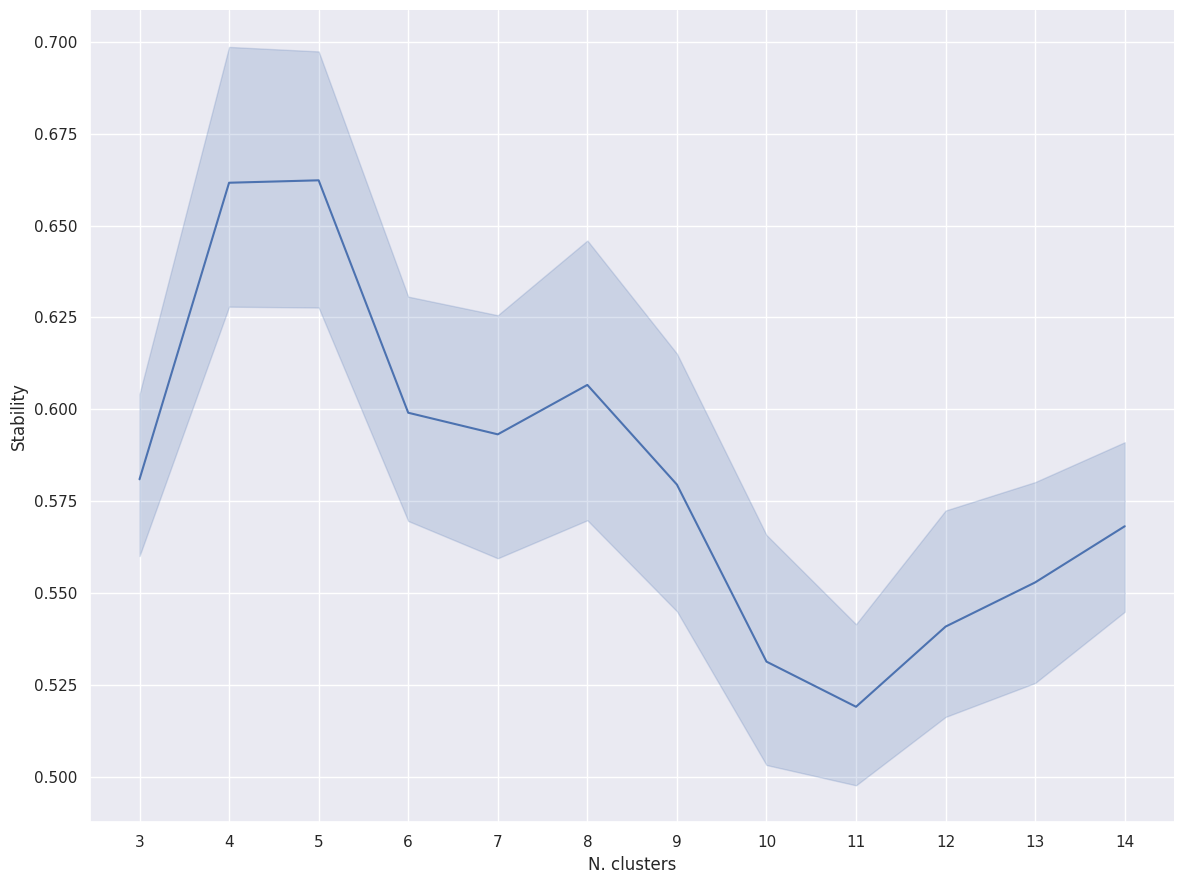

In [63]:
cc.pl.autok_stability(model_bert)
plt.tight_layout()
plt.show()
plt.close()

In [65]:
best_cluster_bert = model_bert.best_k
print(f"In BERT case, {best_cluster_bert} is the best candidate!")
train_anndata.obs['cluster_bert'] = model_bert.predict(train_anndata, use_rep='X_agg_BERT', k=best_cluster_bert)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In BERT case, 5 is the best candidate!


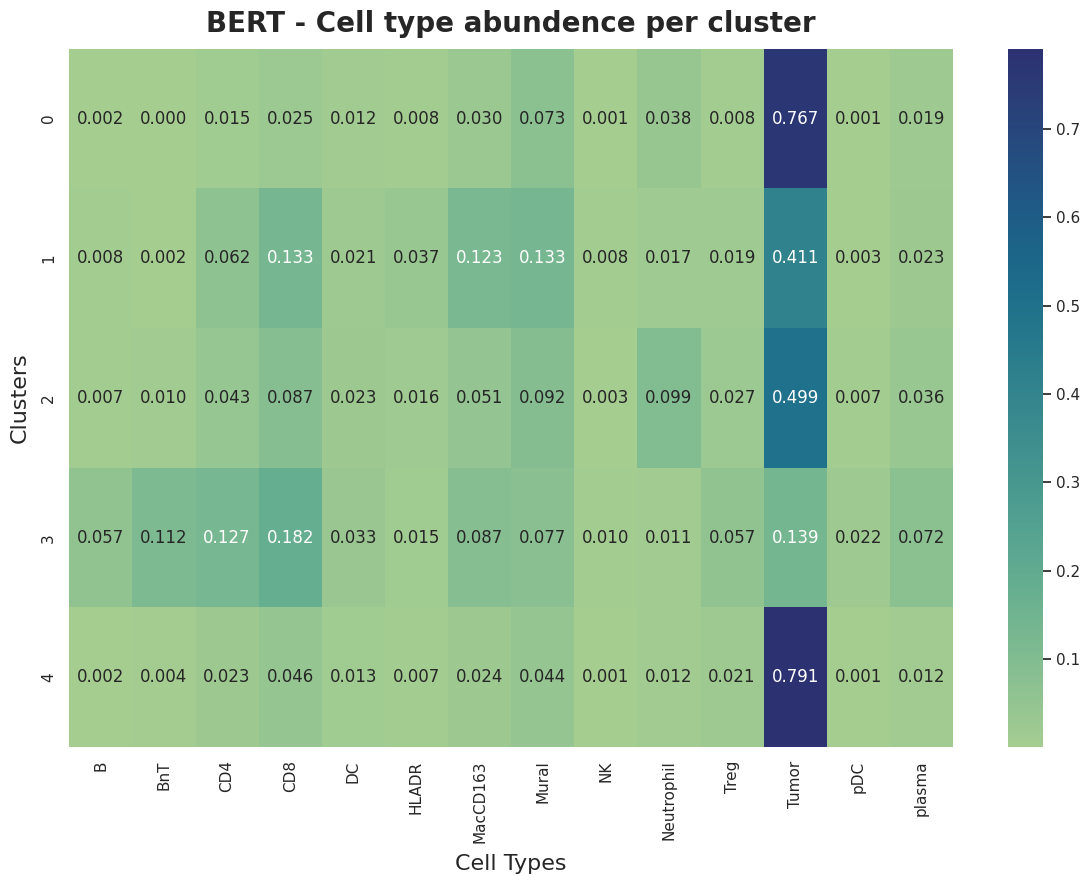

In [66]:
cell_type_abundance = train_anndata.obs.groupby('cluster_bert', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "BERT - Cell type abundence per cluster", ".3f")

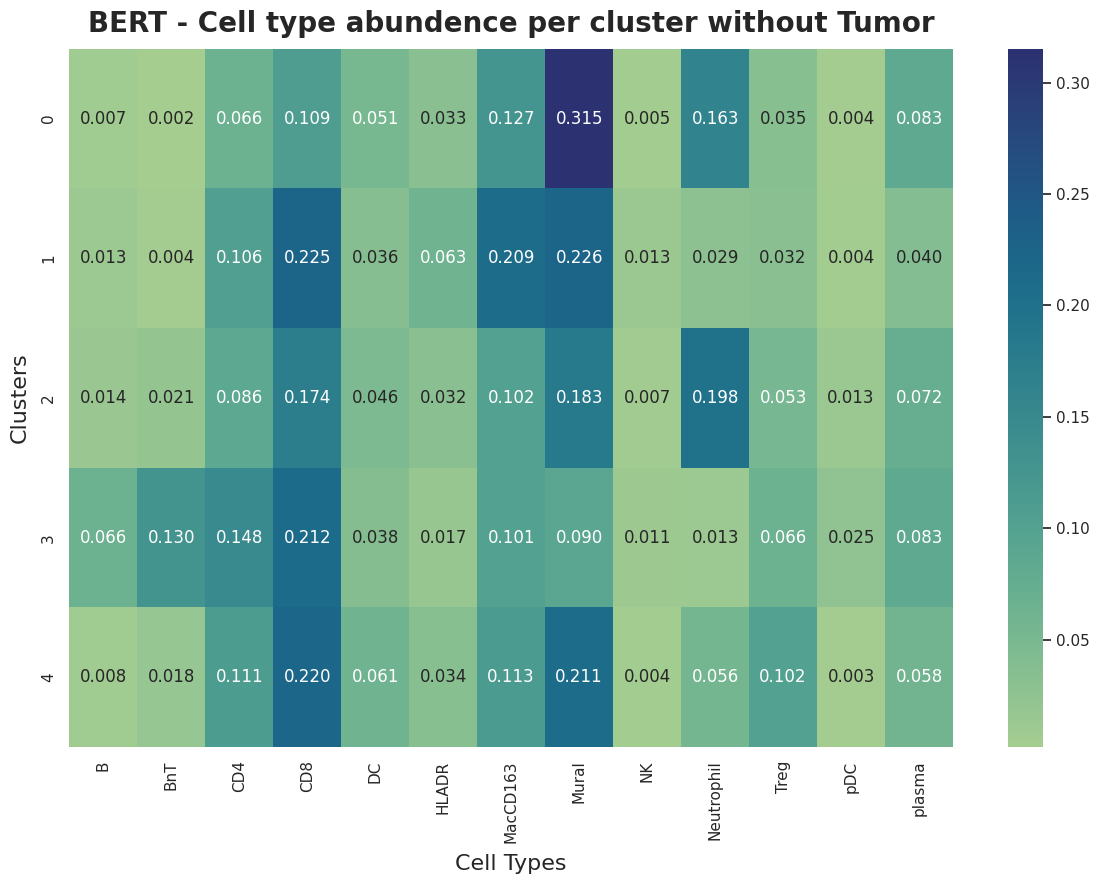

In [67]:
cell_type_abundance = train_anndata.obs.groupby('cluster_bert', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "BERT - Cell type abundence per cluster without Tumor", ".3f")

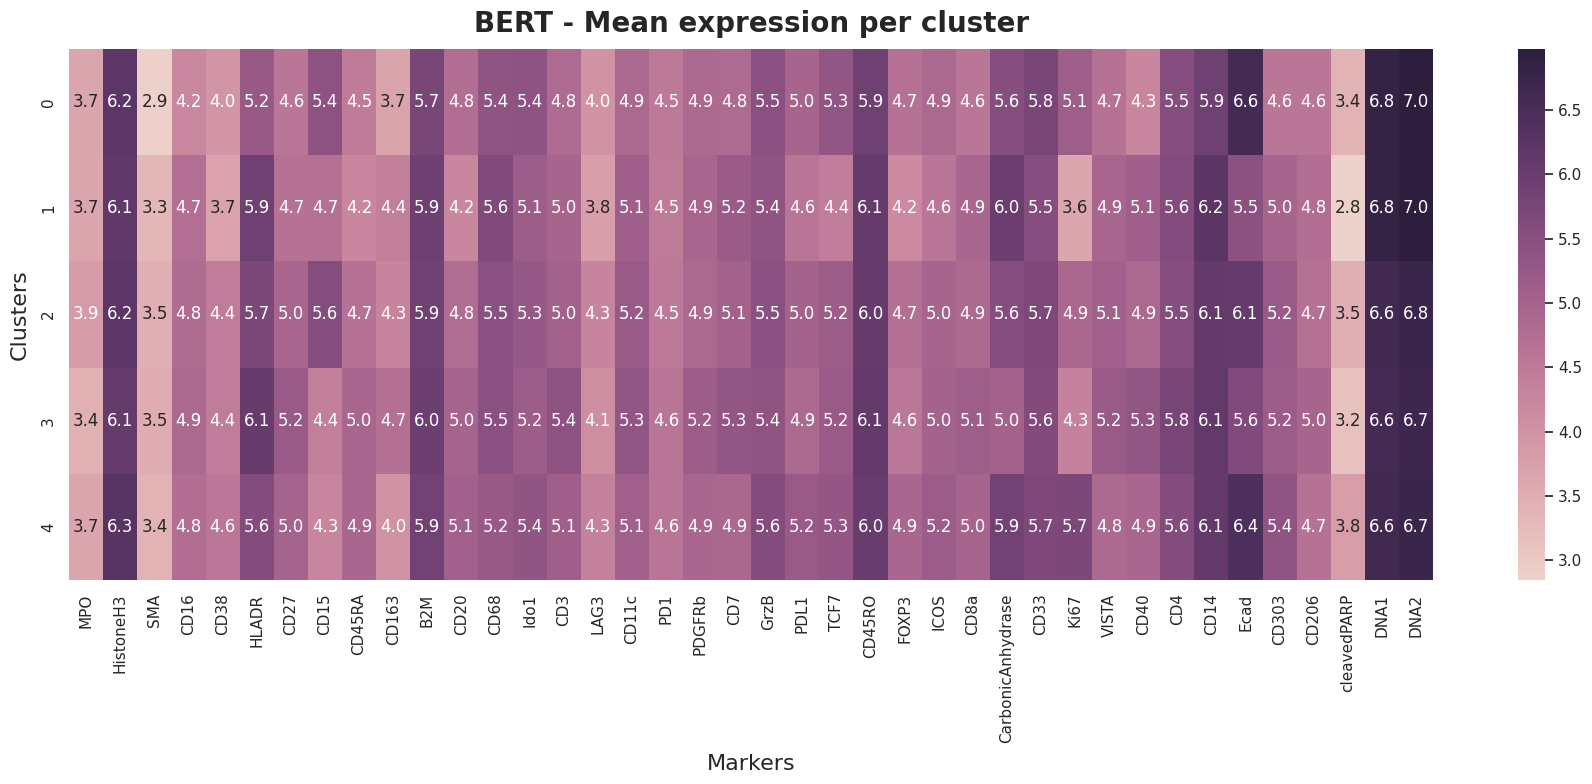

In [70]:
clusters_exprs = []

for cluster in range(best_cluster_bert):
    mask = train_anndata.obs['cluster_bert'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster_bert)]
)

plot_heatmap(expressions_clusters_df, "BERT - Mean expression per cluster", ".1f", (18, 8), "Markers")

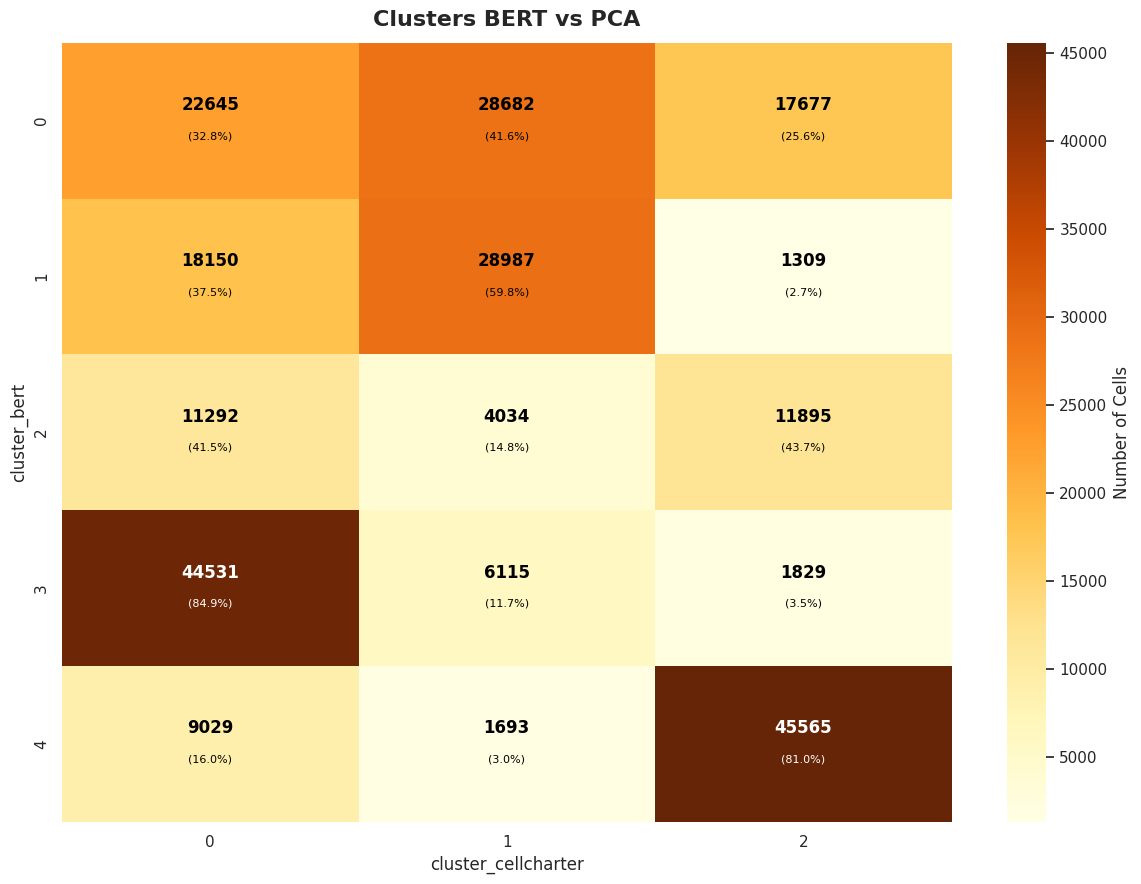

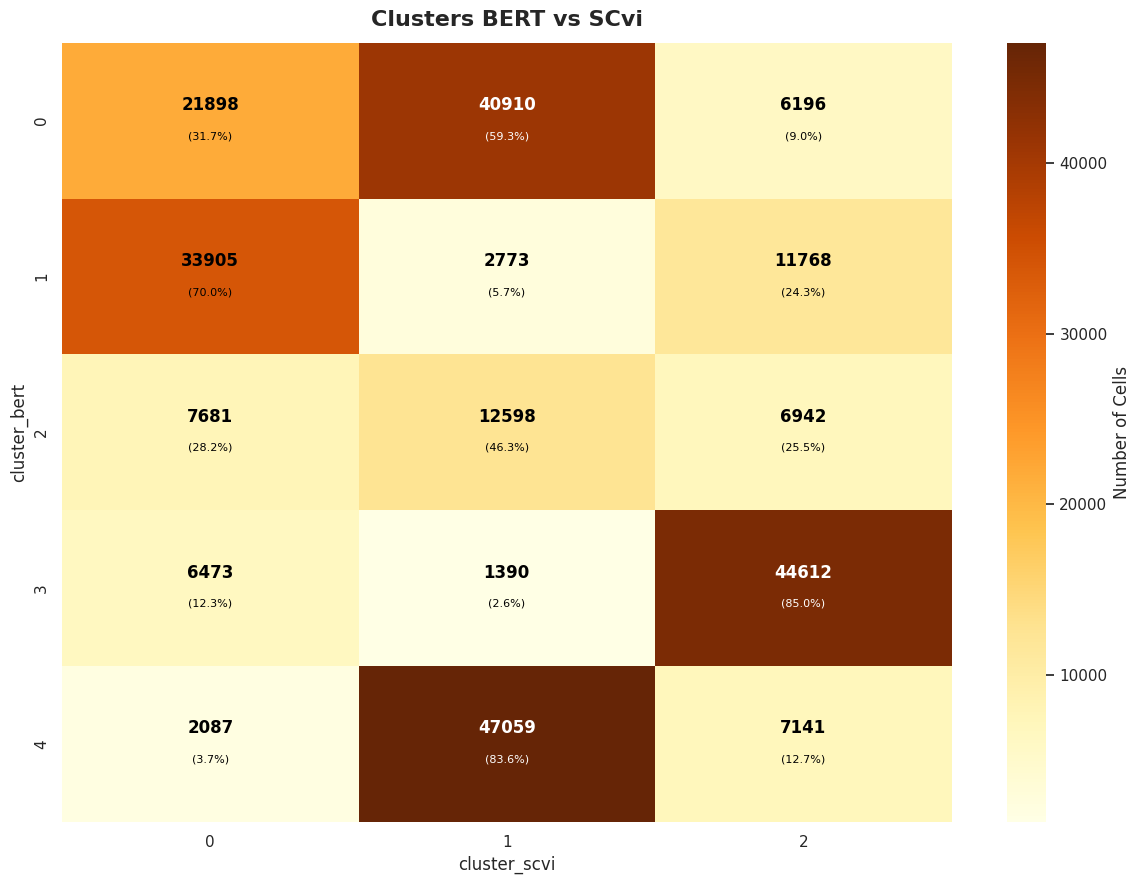

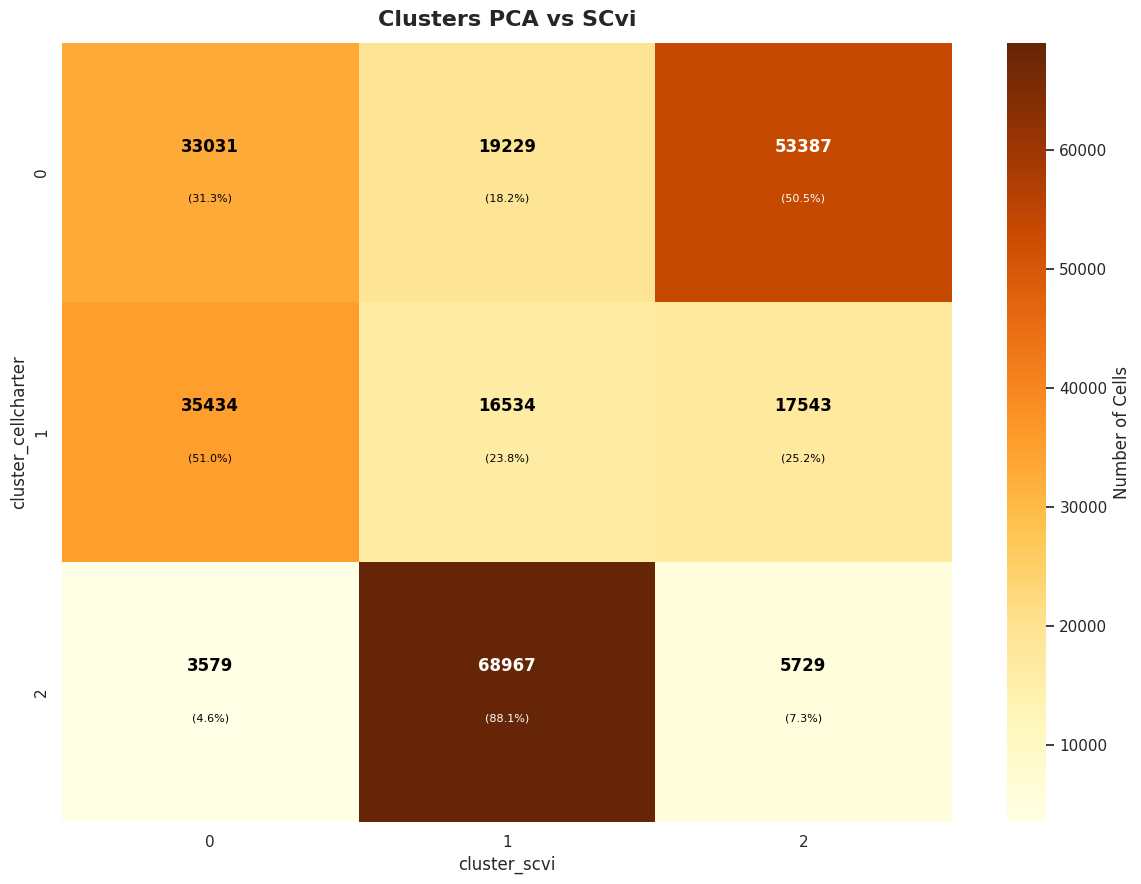

In [71]:
# Comparison of the results
ct_left, ct_right = make_cross_matrix(train_anndata.obs, 'cluster_bert', 'cluster_cellcharter')
plot_cross_heatmap(ct_left, ct_right, f"Clusters BERT vs PCA")

ct_left, ct_right = make_cross_matrix(train_anndata.obs, 'cluster_bert', 'cluster_scvi')
plot_cross_heatmap(ct_left, ct_right, f"Clusters BERT vs SCvi")

ct_left, ct_right = make_cross_matrix(train_anndata.obs, 'cluster_cellcharter', 'cluster_scvi')
plot_cross_heatmap(ct_left, ct_right, f"Clusters PCA vs SCvi")

The BERT-Charter algorithm produced five clusters of varying cancer cell intensity, providing a better explanation of the data than any previous approach. In the cluster with the second-highest number of cancer cells, mural cells also co-occur. However, these cells are not present in the cluster with the lowest number of cancer cells. There, B cells, BnT cells and CD4 cells, which are responsible for the body's immune response, are present. This indicates an active immune response. Conversely, HLADR cells are found in greater numbers in clusters where the fight against cancer is ongoing. There, we observe correlations with a lower frequency of Treg cells and the highest presence of CD8+ cells. Conversely, the cluster with the highest number of tumour cells also has the highest frequency of Treg cells. Where the tumour develops, there is a characteristic increase in the number of neutrophil cells. It seems that, with this differentiation, we should be able to match the cluster to the stage at which the cancer is.

Similar observations can be drawn from marker analysis. The high amount of the SMA marker in clasts with a large number of tumor cells indicates its role in promoting tumorigenesis and influencing tumor nutrition. Incidentally, so does the amount of the cleavedPARP marker, responsible for cell apoptosis, which indicates increased cell death in the tumor environment. On the other hand, in clusters with lower amounts, we observe a lower amount of Ki67, which indicates that there is not yet more proliferation there.

Comparing the number of cells *per cluster* for the different methods shows that only two clusters were mapped in PCA (above 50% each), compared to up to three in the scVI algorithm. The remaining clusters, however, did not map clearly, with the number of cells distributed equally. In my opinion, each cluster obtained using the above algorithm makes more biological sense. For example, it was more difficult for post-mediation methods to mark the stages of tumour development (initiation, promotion and proliferation).

Traditional methods (like PCA) reduce the dimensionality of marker expression data, but do not explicitly account for spatial structure and relationships between cells. scVI handles batch effects and sparsity of data, creating better expression embedding, but still does not directly model local spatial interactions the way BERT-Charter does. That is why the BERT-Charter is the best approach in my opinion.